

WBC Classification: Custom CNN (Baseline Model)

Project Overview

This notebook implements a custom "from-scratch" Convolutional Neural Network (CNN) to serve as a baseline model for White Blood Cell (WBC) classification using the Raabin-WBC dataset.

The primary goal of this experiment is to test the effectiveness of a traditional, "from-scratch" approach in addressing three key research gaps identified in our literature review.

Addressing the Research Gaps

This code is structured to directly investigate the following:

1. The Generalization Gap:

Problem: Models trained on one data source often fail to generalize to new, out-of-domain data (e.g., Test Set B).

Hypothesis: We will test if standard regularization techniques are sufficient to solve this.

Our Approach:

Data Augmentation: Using ImageDataGenerator to create more training variations.

Regularization: Using Batch Normalization after each convolutional layer and Dropout in the classification head to prevent overfitting.

2. The Lightweight XAI Gap:

Problem: Models are often "black boxes" that are too large for clinical devices.

Our Approach:

Computational Baseline: The architecture serves as our computational baseline. It is a traditional 3-block CNN which results in a computationally expensive model with ~7.47M parameters. This will be contrasted with a more modern, efficient architecture.

XAI (Explainable AI): We implement Grad-CAM (Gradient-weighted Class Activation Mapping) to produce heatmaps that visually explain which pixels the model used to make its final classification.

3. The Rare Class Gap:

Problem: The dataset is highly imbalanced, with rare classes (like Basophils) being underrepresented.

Our Approach:

We use a standard Class Weighting scheme (from scikit-learn). This forces the model to pay a higher penalty when it misclassifies a sample from a minority class, encouraging it to learn their features.

In [ ]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization,
                                     Activation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from google.colab import drive

In [3]:


# --- 1. MOUNT DRIVE & COPY DATA TO FAST LOCAL DISK ---
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

ZIP_PATH = "/content/drive/My Drive/Datasets/Raabin-WBC_dataset.zip"
LOCAL_DEST = "/tmp/"
UNZIP_DIR = "/tmp/Raabin-WBC_dataset"

# --- ADD THIS LINE ---
print(f"Cleaning up old temporary data at {UNZIP_DIR}...")
!rm -rf "{UNZIP_DIR}"
# ---------------------

print("Copying dataset zip from Drive to local VM...")
!cp "{ZIP_PATH}" "{LOCAL_DEST}"

# --- MODIFY THIS LINE ---
# Add the -o flag to force overwrite, just in case.
print("Unzipping dataset...")
!unzip -oq /tmp/Raabin-WBC_dataset.zip -d /tmp/
# ------------------------

BASE_DIR = UNZIP_DIR



Mounting Google Drive...
Mounted at /content/drive
Cleaning up old temporary data at /tmp/Raabin-WBC_dataset...
Copying dataset zip from Drive to local VM...
Unzipping dataset...


In [5]:
# --- 2. FIND AND DELETE CORRUPTED FILES (AUTOMATIC) ---
train_dir_scan = os.path.join(BASE_DIR, 'Train')
bad_files = []

print(f"Scanning {train_dir_scan} for corrupted images...")
for root, dirs, files in os.walk(train_dir_scan):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except Exception as e:
            print(f"!!! BAD FILE FOUND: {file_path}")
            bad_files.append(file_path)

if bad_files:
    print(f"\nFound {len(bad_files)} bad file(s). Now deleting them...")
    for f in bad_files:
        print(f"Deleting: {f}")
        os.remove(f)
    print("All bad files have been deleted.")
else:
    print("\nScan complete. No bad files were found.")

Scanning /tmp/Raabin-WBC_dataset/Train for corrupted images...
!!! BAD FILE FOUND: /tmp/Raabin-WBC_dataset/Train/.DS_Store

Found 1 bad file(s). Now deleting them...
Deleting: /tmp/Raabin-WBC_dataset/Train/.DS_Store
All bad files have been deleted.


In [6]:
# --- Define dataset paths based on the Google Drive location ---
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'TestA') # Using Test A for validation
TEST_A_DIR = os.path.join(BASE_DIR, 'TestA') # In-domain test set
TEST_B_DIR = os.path.join(BASE_DIR, 'Test-B') # Out-of-domain test set


In [ ]:

# --- Hyperparameters ---
IMAGE_SIZE = (120, 120)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.0001

# --- 2. DATA PREPARATION & AUGMENTATION (WITH VALIDATION) ---

# --- Find valid classes (non-empty folders) BEFORE creating generators ---
print("Finding valid (non-empty) class subdirectories...")
all_class_folders = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]

valid_class_names = []
for class_folder in all_class_folders:
    folder_path = os.path.join(TRAIN_DIR, class_folder)
    # Check if the folder contains any files
    if len(os.listdir(folder_path)) > 0:
        valid_class_names.append(class_folder)
    else:
        print(f"Warning: Skipping empty class folder: {class_folder}")

valid_class_names.sort()
print(f"Found {len(valid_class_names)} valid classes: {valid_class_names}")

# --- Update NUM_CLASSES to match what we actually found ---
NUM_CLASSES = len(valid_class_names)
# --------------------------------------------------------------------------

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=20.0
)

validation_test_datagen = ImageDataGenerator(rescale=1./255)

# --- Create generators using ONLY the valid_class_names ---
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    classes=valid_class_names
)

validation_generator = validation_test_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=valid_class_names
)

print(f"Class indices found: {train_generator.class_indices}")

test_generator_a = validation_test_datagen.flow_from_directory(
    TEST_A_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False,
    classes=valid_class_names
)

test_generator_b = validation_test_datagen.flow_from_directory(
    TEST_B_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False,
    classes=valid_class_names
)

print(f"Class indices found: {train_generator.class_indices}")

# --- 3. MODEL ARCHITECTURE DEFINITION ---
def build_lightweight_cnn(input_shape, num_classes):
    """Builds a lightweight, custom CNN architecture."""
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_lightweight_cnn(input_shape=IMAGE_SIZE + (3,), num_classes=NUM_CLASSES)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# --- 4. HANDLING CLASS IMBALANCE ---
if os.path.exists(TRAIN_DIR):
    # Convert the generator's classes to integers FIRST
    y_classes = train_generator.classes.astype(int)

    # Get the unique integer labels
    class_labels = np.unique(y_classes)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=class_labels,
        y=y_classes
    )
    class_weights_dict = dict(zip(class_labels, class_weights))
    print("Calculated Class Weights:", class_weights_dict)
else:
    print("Warning: Training directory not found. Using default class weights.")
    class_weights_dict = None

# --- 5. MODEL TRAINING ---
checkpoint = ModelCheckpoint('CNN_best_wbc_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

if os.path.exists(TRAIN_DIR) and os.path.exists(VALIDATION_DIR):
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stopping, lr_scheduler],
        class_weight=class_weights_dict,

    )
else:
    print("\nERROR: Training and/or validation directories not found.")
    print("Please update the BASE_DIR variable to point to your dataset in Google Drive.")
    history = None






Finding valid (non-empty) class subdirectories...
Found 5 valid classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Found 10175 images belonging to 5 classes.
Found 4339 images belonging to 5 classes.
Class indices found: {'Basophil': 0, 'Eosinophil': 1, 'Lymphocyte': 2, 'Monocyte': 3, 'Neutrophil': 4}
Found 4339 images belonging to 5 classes.
Found 2119 images belonging to 5 classes.
Class indices found: {'Basophil': 0, 'Eosinophil': 1, 'Lymphocyte': 2, 'Monocyte': 3, 'Neutrophil': 4}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 120, 120, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,469,509 (28.49 MB)

 Trainable params: 7,468,549 (28.49 MB)

...

318/318 ━━━━━━━━━━━━━━━━━━━━ 109s 342ms/step - accuracy: 0.7590 - loss: 0.6327 - val_accuracy: 0.8451 - val_loss: 0.5357 - learning_rate: 1.0000e-04
Epoch 6/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8008 - loss: 0.5978
Epoch 6: val_accuracy improved from 0.84513 to 0.88615, saving model to CNN_best_wbc_model.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 110s 346ms/step - accuracy: 0.8008 - loss: 0.5977 - val_accuracy: 0.8861 - val_loss: 0.3319 - learning_rate: 1.0000e-04
Epoch 7/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8053 - loss: 0.5413
Epoch 7: val_accuracy did not improve from 0.88615
318/318 ━━━━━━━━━━━━━━━━━━━━ 110s 346ms/step - accuracy: 0.8054 - loss: 0.5412 - val_accuracy: 0.8083 - val_loss: 0.7823 - learning_rate: 1.0000e-04
Epoch 8/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8291 - loss: 0.5093
Epoch 8: val_accuracy did not improve from 0.88615
318/318 ━━━━━━━━━━━━━━━━━━━━ 108s 341ms/step - accuracy: 0.8291 - loss: 0.5093 - val_accuracy: 0.8541 - val_loss: 0.5064 - learning_rate: 1.0000e-04
Epoch 9/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.8444 - loss: 0.4969
Epoch 9: val_accuracy improved from 0.88615 to 0.91680, saving model to CNN_best_wbc_model.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 109s 343ms/step - accuracy: 0.8444 - loss: 0.4968 - val_accuracy: 0.9168 - val_loss: 0.2915 - learning_rate: 1.0000e-04
Epoch 10/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8660 - loss: 0.4441
Epoch 10: val_accuracy did not improve from 0.91680
318/318 ━━━━━━━━━━━━━━━━━━━━ 110s 345ms/step - accuracy: 0.8660 - loss: 0.4441 - val_accuracy: 0.8820 - val_loss: 0.3154 - learning_rate: 1.0000e-04
Epoch 11/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8581 - loss: 0.4311
Epoch 11: val_accuracy improved from 0.91680 to 0.92510, saving model to CNN_best_wbc_model.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 110s 346ms/step - accuracy: 0.8581 - loss: 0.4311 - val_accuracy: 0.9251 - val_loss: 0.2340 - learning_rate: 1.0000e-04
Epoch 12/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8649 - loss: 0.4266
Epoch 12: val_accuracy did not improve from 0.92510
318/318 ━━━━━━━━━━━━━━━━━━━━ 108s 341ms/step - accuracy: 0.8650 - loss: 0.4265 - val_accuracy: 0.7831 - val_loss: 0.7763 - learning_rate: 1.0000e-04
Epoch 13/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8699 - loss: 0.3871
Epoch 13: val_accuracy improved from 0.92510 to 0.93893, saving model to CNN_best_wbc_model.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 108s 340ms/step - accuracy: 0.8699 - loss: 0.3871 - val_accuracy: 0.9389 - val_loss: 0.1872 - learning_rate: 1.0000e-04
Epoch 14/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8844 - loss: 0.3646
Epoch 14: val_accuracy did not improve from 0.93893
318/318 ━━━━━━━━━━━━━━━━━━━━ 107s 337ms/step - accuracy: 0.8844 - loss: 0.3647 - val_accuracy: 0.8670 - val_loss: 0.5010 - learning_rate: 1.0000e-04
Epoch 15/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8749 - loss: 0.3731
Epoch 15: val_accuracy did not improve from 0.93893
318/318 ━━━━━━━━━━━━━━━━━━━━ 106s 332ms/step - accuracy: 0.8749 - loss: 0.3731 - val_accuracy: 0.8944 - val_loss: 0.3437 - learning_rate: 1.0000e-04
Epoch 16/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8852 - loss: 0.3716
Epoch 16: val_accuracy did not improve from 0.93893
318/318 ━━━━━━━━━━━━━━━━━━━━ 108s 340ms/step - accuracy: 0.8852 - loss: 0.3716 - val_accuracy: 0.8440 - val_loss: 0.5878 - learnin

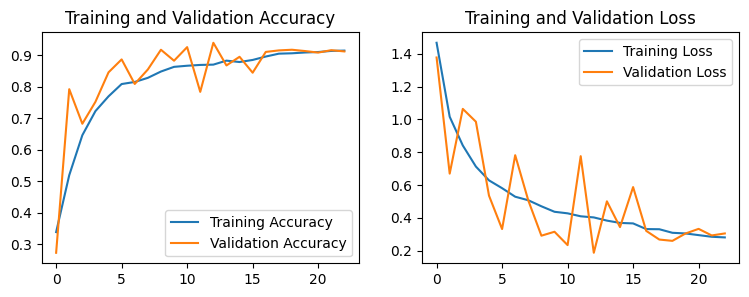


--- Evaluating on Test Set A (In-Domain) ---
4339/4339 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9123 - loss: 0.2701
Test Set A (In-Domain) Accuracy: 0.9389
Test Set A (In-Domain) Loss: 0.1872
4339/4339 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step

--- Test Set A (In-Domain) Classification Report ---
              precision    recall  f1-score   support

    Basophil       0.98      0.99      0.98        89
  Eosinophil       0.85      0.85      0.85       322
  Lymphocyte       0.97      0.91      0.94      1034
    Monocyte       0.76      0.71      0.73       234
  Neutrophil       0.95      0.98      0.96      2660

    accuracy                           0.94      4339
   macro avg       0.90      0.89      0.89      4339
weighted avg       0.94      0.94      0.94      4339


--- Test Set A (In-Domain) Confusion Matrix ---


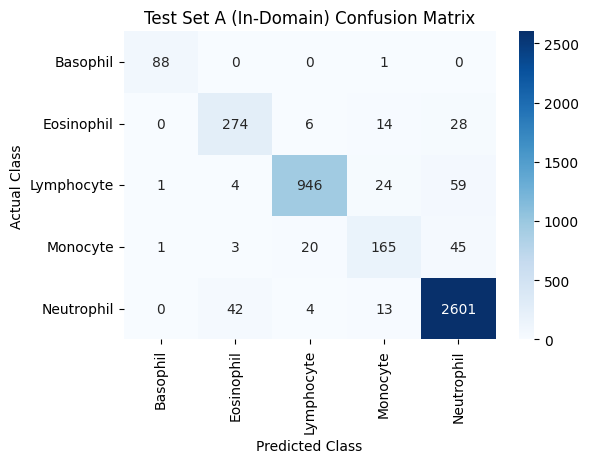


--- Evaluating on Test Set B (Out-of-Domain) ---
  16/2119 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.0000e+00 - loss: 12.7099

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2119/2119 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.1631 - loss: 4.4853
Test Set B (Out-of-Domain) Accuracy: 0.3181
Test Set B (Out-of-Domain) Loss: 2.7724
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step

--- Test Set B (Out-of-Domain) Classification Report ---
              precision    recall  f1-score   support

  Lymphocyte       1.00      0.01      0.01       148
  Neutrophil       0.97      0.34      0.51      1971

   micro avg       0.97      0.32      0.48      2119
   macro avg       0.99      0.17      0.26      2119
weighted avg       0.98      0.32      0.47      2119


--- Test Set B (Out-of-Domain) Confusion Matrix ---


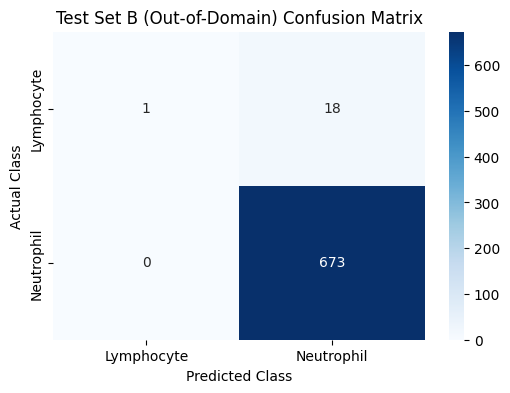

In [ ]:
# --- 6. MODEL EVALUATION ---
def plot_training_history(history):
    """Plots accuracy and loss curves for training and validation."""
    plt.figure(figsize=(9, 3))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

if history:
    plot_training_history(history)

def evaluate_model(model, test_generator, test_set_name):
    """Evaluates the model on a given test set and prints the results."""
    print(f"\n--- Evaluating on {test_set_name} ---")
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"{test_set_name} Accuracy: {test_acc:.4f}")
    print(f"{test_set_name} Loss: {test_loss:.4f}")

    test_generator.reset()
    Y_pred = model.predict(test_generator, steps=test_generator.samples)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes

    class_names = list(train_generator.class_indices.keys())
    report_class_indices = sorted(np.unique(y_true))
    report_class_names = [class_names[i] for i in report_class_indices]

    print(f"\n--- {test_set_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=report_class_names, labels=report_class_indices))

    print(f"\n--- {test_set_name} Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred, labels=report_class_indices)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=report_class_names, yticklabels=report_class_names)
    plt.title(f'{test_set_name} Confusion Matrix')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

if os.path.exists('CNN_best_wbc_model.h5'):
    best_model = tf.keras.models.load_model('CNN_best_wbc_model.h5')

    if os.path.exists(TEST_A_DIR):
        evaluate_model(best_model, test_generator_a, "Test Set A (In-Domain)")
    else:
        print("\nWarning: Test A directory not found. Skipping evaluation.")

    if os.path.exists(TEST_B_DIR):
        evaluate_model(best_model, test_generator_b, "Test Set B (Out-of-Domain)")
    else:
        print("\nWarning: Test B directory not found. Skipping evaluation.")
else:
    print("\nWarning: 'best_wbc_model.h5' not found. Skipping final evaluation.")


Pred idx=4, prob=0.4032


/tmp/ipykernel_854/502159284.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


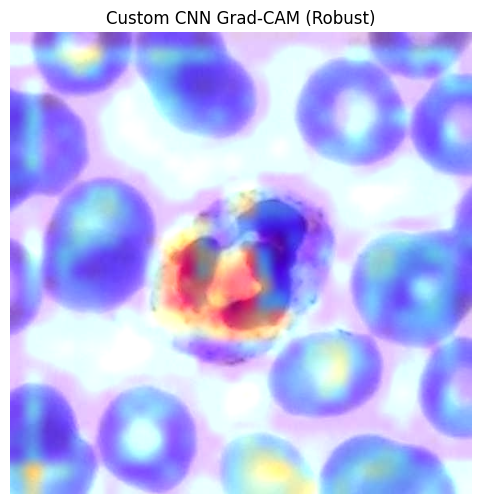

In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 1. Initialize paths and load the trained custom CNN weights
MODEL_PATH = 'CNN_best_wbc_model.h5'
SAMPLE_IMAGE_PATH = os.path.join(TEST_A_DIR, 'Neutrophil', '95-8-6-1_50_2.jpg')
IMAGE_SIZE = (120, 120)

assert os.path.exists(MODEL_PATH), f"Missing model: {MODEL_PATH}"
assert os.path.exists(SAMPLE_IMAGE_PATH), f"Missing image: {SAMPLE_IMAGE_PATH}"

custom_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# 2. Define utility function to overlay and render the heatmap on the input sample
def show_custom_gradcam(img_path, heatmap, alpha=0.5):
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)
    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed = jet_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 255)
    superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.axis('off')
    plt.title('Custom CNN Grad-CAM (Robust)')
    plt.show()

# 3. Load and preprocess the target image tensor
img_loaded = tf.keras.preprocessing.image.load_img(SAMPLE_IMAGE_PATH, target_size=IMAGE_SIZE)
img_arr = tf.keras.preprocessing.image.img_to_array(img_loaded) / 255.0
img_tensor = tf.convert_to_tensor(np.expand_dims(img_arr, axis=0))

# 4. Extract feature maps up to the target convolutional activation layer
conv_base_sub = tf.keras.models.Model(
    inputs=custom_model.input,
    outputs=custom_model.get_layer('activation_2').output  # Target the final activation layer of block 3
)

with tf.GradientTape() as tape:
    conv_outputs = conv_base_sub(img_tensor)
    tape.watch(conv_outputs)

    # Forward pass through the remaining classifier layers sequentially
    x = custom_model.get_layer('max_pooling2d_2')(conv_outputs)
    x = custom_model.get_layer('dropout')(x)
    x = custom_model.get_layer('flatten')(x)
    x = custom_model.get_layer('dense')(x)
    x = custom_model.get_layer('batch_normalization_3')(x)
    x = custom_model.get_layer('dropout_1')(x)
    logits = custom_model.get_layer('dense_1')(x)
    preds = tf.nn.softmax(logits)

    pred_index = tf.argmax(preds[0])
    target = preds[0, pred_index]

# 5. Compute gradients and construct the final Grad-CAM heatmap array
grads = tape.gradient(target, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
heatmap = heatmap.numpy()

print(f"Pred idx={int(pred_index.numpy())}, prob={float(preds[0, pred_index]):.4f}")
show_custom_gradcam(SAMPLE_IMAGE_PATH, heatmap)